In [ ]:
import tdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyranges as pr
from sklearn.decomposition import PCA
import seaborn as sb
import sys
import trf
from scipy.stats import pearsonr
import matplotlib.colors as mcolors
import functools
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
import regex as re
from joypy import joyplot

# import my own modules
# import my own modules
sys.path.insert(0, "../QC_scripts")
from QC_utils import *  # my QC functions
sys.path.insert(0, "..")
from analysis_utils import *  # tdb functions for downstream analysis

In [2]:
def get_base_composition(motif):
    return ''.join(sorted(set(motif)))

In [ ]:
# load the data
# load data
LPS = pd.read_csv("../feature_generation_scripts/LPS_metrics_with_annotations.tsv.gz", compression="gzip", sep="\t")

# add columns for plotting
major_families = ["non_mei", "Retroposon_SVA", "LINE_L1", "LINE_L2", "SINE_Alu"]
mei_family_order = ["non-MEI","Alu","LINE1","LINE2","SVA"]
relative_pos_order =["non-MEI","5'","internal","3'"]
# add a plotting value for the major families names
LPS["mei_family_plot"] = LPS["mei_family"].replace({
    "non_mei": "non-MEI",
    "Retroposon_SVA": "SVA",
    "LINE_L1": "LINE1",
    "LINE_L2": "LINE2",
    "SINE_Alu": "Alu"
})
LPS["relative_pos_plot"] = LPS["terminal_label"].replace({
    "5'terminal": "5'",
    "3'terminal": "3'",
    "internal": "internal",
    "non_mei": "non-MEI"
})

# get variable/polymorphic regions labled
LPS["variable"] = LPS["Stdev"] > 0
# update XDP locus since it is split across 2 which messes with its plotting
LPS.loc[LPS.LocusID.isin([4383298.0, 4383299.0]), ['disease_id', 'disease_associated', 'terminal_label']] = ['XDP', True, "5'terminal"]

# get detected_period as the period of the lps motif
LPS["detected_period"] = LPS["most_common_motif"].str.len()
#get base composition from the simple_motif based on the most common motif
LPS["simple_motif"] = LPS["most_common_motif"].apply(SequenceAttributes.get_simple_motif)
LPS["base_composition"] = LPS["simple_motif"].apply(get_base_composition).apply(SequenceAttributes.get_simple_motif)

LPS

,LocusID,chrom,start,end,Mean,Stdev,unique_lps,disease_associated,exclusion_type,str_period,...,end_mei,internal_external,terminal_label,GencodeGeneRegion,mei_family_plot,relative_pos_plot,variable,detected_period,simple_motif,base_composition
0,15,chr1,14068,14081,12.000000,0.000000,1,False,keep,4.0,...,NaN,non_mei,non_mei,exon,non-MEI,non-MEI,False,4,AGGG,AG
1,16,chr1,15810,15822,5.887500,1.894028,3,False,keep,3.0,...,NaN,non_mei,non_mei,exon,non-MEI,non-MEI,True,3,AGC,ACG
2,17,chr1,16618,16632,11.944099,0.707093,2,False,keep,3.0,...,NaN,non_mei,non_mei,exon,non-MEI,non-MEI,True,3,AGC,ACG
3,18,chr1,16715,16727,8.981366,0.235698,2,False,keep,3.0,...,NaN,non_mei,non_mei,exon,non-MEI,non-MEI,True,3,ACC,AC
4,19,chr1,19174,19184,9.000000,0.000000,1,False,keep,3.0,...,NaN,non_mei,non_mei,intron,non-MEI,non-MEI,False,3,AGG,AG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2382409,4542948,chr4,3074875,3075040,6.345000,0.957066,2,False,keep,3.0,...,NaN,non_mei,non_mei,NaN,non-MEI,non-MEI,True,3,AGG,AG
2382410,4542949,chr4,3074875,3075040,9.000000,0.000000,1,False,keep,3.0,...,NaN,non_mei,non_mei,NaN,non-MEI,non-MEI,False,3,CCG,CG
2382411,4542950,chr4,3074875,3075040,8.969849,0.299238,2,False,keep,3.0,...,NaN,non_mei,non_mei,NaN,non-MEI,non-MEI,True,3,CCG,CG
2382412,4542951,chr13,70139350,70139428,44.640000,36.198901,18,True,keep,3.0,...,NaN,non_mei,non_mei,CDS,non-MEI,non-MEI,True,3,AGC,ACG


In [ ]:
updated_labels = pd.read_csv('../feature_generation_scripts/final_labels_manuscript.tsv', sep='\t')
# merge with LPS to get the STR_classification
LPS = LPS.merge(updated_labels[['chrom', 'start', 'end', 'STR_classification','keep_rel_pos']], on=['chrom', 'start', 'end'], how='left')
LPS.keep_rel_pos.value_counts()

/tmp/ipykernel_2338533/3548390495.py:1: DtypeWarning: Columns (3,9,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  updated_labels = pd.read_csv('final_labels_manuscript.tsv', sep='\t')


keep_rel_pos
True     2359832
False      22537
Name: count, dtype: int64

In [5]:
# for this analysis we will only consider variable regions or regions that have ambiguous MEI assignments
LPS_variable = LPS[(LPS["Stdev"] > 0)&(LPS.keep_rel_pos)].copy()
LPS_variable["plot_label"] = np.select(
    [
        LPS_variable["mei_family"].str.contains("Alu", na=False),
        LPS_variable["mei_family"].str.contains("SVA", na=False),
        LPS_variable["mei_family"].str.contains("L1", na=False),
        LPS_variable["mei_family"].str.contains("L2", na=False),
    ],
    ["Alu", "SVA", "LINE1", "LINE2"],
    default="non-TE",
)
LPS_variable.plot_label.value_counts()

plot_label
non-TE    243353
Alu        96898
LINE1      67230
LINE2      14487
SVA          878
Name: count, dtype: int64

In [6]:
to_sort_by = [x for x in ["non-TE", "SVA","Alu", "LINE1", "LINE2"]]
color_indeces = ["non-TE", "SVA", "Alu", "LINE1", "LINE2"]
# assign explicit colors per plot_label and pass them to joyplot
palette = sb.color_palette("Set2", n_colors=len(to_sort_by) + 1)
palette = [c for idx, c in enumerate(palette)][:len(to_sort_by)]  # keep previous skipping
colors_map = dict(zip(to_sort_by, palette))
colors_map

{'non-TE': (0.4, 0.7607843137254902, 0.6470588235294118),
 'SVA': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 'Alu': (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 'LINE1': (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 'LINE2': (0.6509803921568628, 0.8470588235294118, 0.32941176470588235)}

In [ ]:
plot_dir="/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/manuscript_figures/figure_3_manuscript"

# Figure 3A
FIXME update dimensions and font sizes

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)
/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,
/tmp/ipykernel_2338533/1904306875.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = LPS_ACC.groupby("plot_label").size()


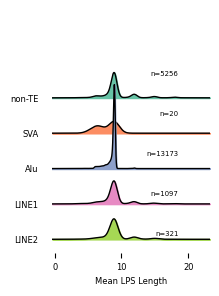

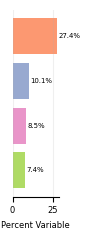

non-TE: Mean LPS = 9.92, Mean Stdev = 0.89
SVA: Mean LPS = 7.75, Mean Stdev = 1.23
Alu: Mean LPS = 8.60, Mean Stdev = 0.75
LINE1: Mean LPS = 9.21, Mean Stdev = 0.86
LINE2: Mean LPS = 9.50, Mean Stdev = 0.76


In [8]:
#plot a joyplot
# set the order of the plot_label to non-MEI, SVA, Alu, LINE1, LINE2
LPS_ACC = LPS_variable[(LPS_variable.simple_motif == "ACC")&((LPS_variable.terminal_label == "internal")|(LPS_variable.mei == False))].copy()
LPS_ACC["plot_label"] = np.select(
    [
        LPS_ACC["mei_family"].str.contains("Alu", na=False),
        LPS_ACC["mei_family"].str.contains("SVA", na=False),
        LPS_ACC["mei_family"].str.contains("L1", na=False),
        LPS_ACC["mei_family"].str.contains("L2", na=False),
    ],
    ["Alu", "SVA", "LINE1", "LINE2"],
    default="non-TE",
)
to_sort_by = [x for x in ["non-TE", "SVA", "Alu", "LINE1", "LINE2"] if x in LPS_ACC["plot_label"].unique()]
LPS_ACC["plot_label"] = pd.Categorical(LPS_ACC["plot_label"], categories=to_sort_by, ordered=True)
colors_subset = [colors_map[c] for c in to_sort_by]
fig = plt.figure(figsize=(2.5,3))
axes = joyplot(
    data=LPS_ACC[(LPS_ACC.Mean < 20)&(LPS_ACC.Stdev > 0)],
    by="plot_label",
    column="Mean",
    kind="kde",
    overlap=1,
    linewidth=1,
    color=colors_subset,  # use `color` not `colors`
    ax=plt.gca(),       # remove unsupported `order` argument
)
# set y-axis group label font size to 6
if isinstance(axes, tuple) and len(axes) > 1:
    axes_list = axes[1]
else:
    axes_list = axes if isinstance(axes, (list, tuple)) else [axes]
for a in axes_list:
    a.tick_params(axis='y', labelsize=6)
plt.xlabel('Mean LPS Length', fontsize=6)
# plt.title("Mean LPS length for ACC motif, internal and non-MEI", fontsize=7)
plt.gca().tick_params(axis='both', labelsize=6)  # set tick label size
# add the number of STRs in each group to the plot to the right of the density curves above the distribution for each
group_counts = LPS_ACC.groupby("plot_label").size()
y_max = plt.gca().get_ylim()[1]
for i, group in enumerate(to_sort_by):
    count = group_counts.get(group, 0)
    plt.text(0.80, y_max * (0.75 - i * 0.165), f"n={count}", transform=plt.gca().transAxes, ha="right", va="top", fontsize=5)
# plt.tight_layout()
plt.savefig(f"{plot_dir}/figure3_ACC_mean_lps.pdf", dpi=300, bbox_inches="tight")
plt.show()

# plot the percentage of variable STRs for the ACC motif by plot_label and terminal_label as a vertical bar plot with color corresponding to the plot_label hue in the previous plots and plot it such that the y-axis heights correspond to the same heights as the density plot for the ACC motif (so we can visually compare the percentage variable to the density distribution)
# add plot_label to LPS if it doesn't exist
if "plot_label" not in LPS.columns:
    LPS["plot_label"] = np.select(
        [
            LPS["mei_family"].str.contains("Alu", na=False),
            LPS["mei_family"].str.contains("SVA", na=False),
            LPS["mei_family"].str.contains("L1", na=False),
            LPS["mei_family"].str.contains("L2", na=False),
        ],
        ["Alu", "SVA", "LINE1", "LINE2"],
        default="non-MEI",
    )
ACC_pct_df = LPS[LPS.simple_motif == "ACC"].groupby(["plot_label", "terminal_label"], as_index=False).size().rename(columns={"size": "n_total"})
ACC_variable_df = LPS[(LPS.simple_motif == "ACC")&(LPS.unique_lps > 1)].groupby(["plot_label", "terminal_label"], as_index=False).size().rename(columns={"size": "n_variable"})
ACC_pct_df = ACC_pct_df.merge(ACC_variable_df, on=["plot_label", "terminal_label"], how="left")
ACC_pct_df["n_variable"] = ACC_pct_df["n_variable"].fillna(0)
ACC_pct_df["pct_variable"] = 100 * ACC_pct_df["n_variable"] / ACC_pct_df["n_total"]

# Filter to only include the terminal_label categories that are in to_sort_by or non_mei for non-MEI
ACC_pct_df = ACC_pct_df[
    ((ACC_pct_df.plot_label != "non-TE") & (ACC_pct_df.terminal_label.isin(["5_prime", "internal", "3_prime"]))) |
    ((ACC_pct_df.plot_label == "non-TE") & (ACC_pct_df.terminal_label == "non_mei"))
]

# plot this as a horizontal bar plot with color corresponding to the plot_label hue in the previous plots
fig, ax = plt.subplots(figsize=(1, 2.5))
palette = sb.color_palette("Set2", n_colors=len(to_sort_by) + 1)
palette = [c for idx, c in enumerate(palette) ][:len(to_sort_by)]  # skip 3rd color
colors = dict(zip(to_sort_by, palette))

y_pos = 0
y_labels = []
y_ticks = []

for i, group in enumerate(to_sort_by[::-1]):
    group_data = ACC_pct_df[ACC_pct_df.plot_label == group]
    if group == "non-TE": 
        term_order = ["non_mei"]
    else:
        term_order = ["5_prime", "internal", "3_prime"]
    
    for term in term_order:
        term_data = group_data[group_data.terminal_label == term]
        if not term_data.empty:
            pct = term_data.pct_variable.values[0]
            ax.barh(y_pos, pct, color=colors[group], alpha=0.9)
            y_labels.append(f"{group} - {term}")
            y_ticks.append(y_pos)
            y_pos += 1

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=6)
ax.set_xlabel("Percent Variable", fontsize=6)
ax.grid(axis="x", alpha=0.2)
ax.tick_params(axis='both', labelsize=6)  # set tick label size

# add the percentage value to the right of each bar
for i, (y, label) in enumerate(zip(y_ticks, y_labels)):
    pct = ACC_pct_df[(ACC_pct_df.plot_label == label.split(" - ")[0]) & 
                      (ACC_pct_df.terminal_label == label.split(" - ")[1])].pct_variable.values[0]
    ax.text(pct + 1, y, f"{pct:.1f}%", va="center", fontsize=5)
# remove the y-axis label since it's redundant with the labels we added to the right of the bars
ax.set_yticks([])
# remove the box around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# remove the y axis line
ax.spines['left'].set_visible(False)

plt.tight_layout()
# save the figure
plt.savefig(f"{plot_dir}/figure3_ACC_pct_variable.pdf", dpi=300, bbox_inches="tight")
plt.show()

# print the mean Mean and mean Stdev for each group in the ACC motif subset
for group in to_sort_by:
    group_data = LPS_ACC[LPS_ACC.plot_label == group]
    mean_lps = group_data.Mean.mean()
    mean_stdev = group_data.Stdev.mean()
    print(f"{group}: Mean LPS = {mean_lps:.2f}, Mean Stdev = {mean_stdev:.2f}")

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)
/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,
/tmp/ipykernel_2338533/397397723.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = LPS_ACC.groupby("plot_label").size()


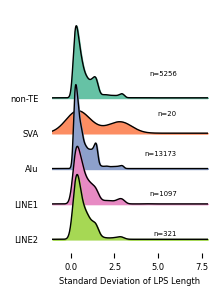

In [9]:
# supplementary: log10 of standard deviation for the same groups
fig = plt.figure(figsize=(2.5,3))
axes = joyplot(
    data=LPS_ACC[(LPS_ACC.Mean < 20)&(LPS_ACC.Stdev > 0)],
    by="plot_label",
    column="Stdev",
    kind="kde",
    overlap=1,
    linewidth=1,
    color=colors_subset,  # use `color` not `colors`
    ax=plt.gca(),       # remove unsupported `order` argument
)
# set y-axis group label font size to 6
if isinstance(axes, tuple) and len(axes) > 1:
    axes_list = axes[1]
else:
    axes_list = axes if isinstance(axes, (list, tuple)) else [axes]
for a in axes_list:
    a.tick_params(axis='y', labelsize=6)
plt.xlabel('Standard Deviation of LPS Length', fontsize=6)
# plt.title("Standard Deviation of LPS length for ACC motif, internal and non-MEI", fontsize=7)
plt.gca().tick_params(axis='both', labelsize=6)  # set tick label size
# add the number of STRs in each group to the plot to the right of the density curves above the distribution for each
group_counts = LPS_ACC.groupby("plot_label").size()
y_max = plt.gca().get_ylim()[1]
for i, group in enumerate(to_sort_by):
    count = group_counts.get(group, 0)
    plt.text(0.80, y_max * (0.75 - i * 0.165), f"n={count}", transform=plt.gca().transAxes, ha="right", va="top", fontsize=5)
# plt.tight_layout()
plt.savefig(f"{plot_dir}/supplementary_fig3_ACC_stdev_lps.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3B

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)
/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,
/tmp/ipykernel_2338533/2585701457.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = LPS_AATG.groupby("plot_label").size()


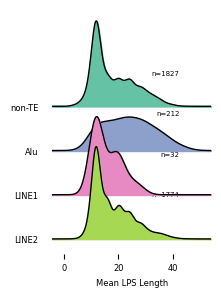

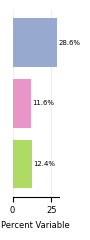

non-TE: Mean LPS = 17.92, Mean Stdev = 1.43
Alu: Mean LPS = 23.85, Mean Stdev = 1.95
LINE1: Mean LPS = 15.77, Mean Stdev = 1.10
LINE2: Mean LPS = 17.52, Mean Stdev = 1.33


In [10]:
# plot a joyplot
# set the order of the plot_label to non-MEI, SVA, Alu, LINE1, LINE2
# get LPS_AATG for 3' and non-MEI, don't include SVA since there are none
LPS_AATG = LPS_variable[(LPS_variable.simple_motif == "AATG")&((LPS_variable.terminal_label == "3'terminal")|(LPS_variable.mei == False))].copy()
LPS_AATG["plot_label"] = np.select(
    [
        LPS_AATG["mei_family"].str.contains("Alu", na=False),
        LPS_AATG["mei_family"].str.contains("SVA", na=False),
        LPS_AATG["mei_family"].str.contains("L1", na=False),
        LPS_AATG["mei_family"].str.contains("L2", na=False),
    ],
    ["Alu", "SVA", "LINE1", "LINE2"],
    default="non-TE",
)
to_sort_by = [x for x in ["non-TE", "SVA", "Alu", "LINE1", "LINE2"] if x in LPS_AATG["plot_label"].unique()]
# filter SVA
LPS_AATG = LPS_AATG[~LPS_AATG.plot_label.isin(["SVA"])]
LPS_AATG["plot_label"] = pd.Categorical(LPS_AATG["plot_label"], categories=to_sort_by, ordered=True)

# given the color_list get the subset that corresponds to plot_label in LPS_AATG
colors_subset = [colors_map[c] for c in to_sort_by]

fig = plt.figure(figsize=(2.5, 3))
axes = joyplot(
    data=LPS_AATG[LPS_AATG.Stdev > 0],
    by="plot_label",
    column="Mean",
    kind="kde",
    overlap=1,
    linewidth=1,
    color=colors_subset,
    ax=plt.gca(),
)
# set y-axis group label font size to 6
if isinstance(axes, tuple) and len(axes) > 1:
    axes_list = axes[1]
else:
    axes_list = axes if isinstance(axes, (list, tuple)) else [axes]
for a in axes_list:
    a.tick_params(axis='y', labelsize=6)
plt.xlabel("Mean LPS Length", fontsize=6)
plt.gca().tick_params(axis='both', labelsize=6)

# add counts to the right of each density curve
group_counts = LPS_AATG.groupby("plot_label").size()
y_max = plt.gca().get_ylim()[1]
for i, group in enumerate(to_sort_by):
    count = group_counts.get(group, 0)
    plt.text(0.80, y_max * (0.75 - i * 0.165), f"n={count}", transform=plt.gca().transAxes, ha="right", va="top", fontsize=5)

# plt.tight_layout()
plt.savefig(f"{plot_dir}/figure3_AATG_mean_lps.pdf", dpi=300, bbox_inches="tight")
plt.show()

# plot the percentage of variable STRs for the AATG motif by plot_label and terminal_label
if "plot_label" not in LPS.columns:
    LPS["plot_label"] = np.select(
        [
            LPS["mei_family"].str.contains("Alu", na=False),
            LPS["mei_family"].str.contains("SVA", na=False),
            LPS["mei_family"].str.contains("L1", na=False),
            LPS["mei_family"].str.contains("L2", na=False),
        ],
        ["Alu", "SVA", "LINE1", "LINE2"],
        default="non-TE",
    )
ACC_pct_df = LPS[LPS.simple_motif == "AATG"].groupby(["plot_label", "terminal_label"], as_index=False).size().rename(columns={"size": "n_total"})
ACC_variable_df = LPS[(LPS.simple_motif == "AATG")&(LPS.unique_lps > 1)].groupby(["plot_label", "terminal_label"], as_index=False).size().rename(columns={"size": "n_variable"})
ACC_pct_df = ACC_pct_df.merge(ACC_variable_df, on=["plot_label", "terminal_label"], how="left")
ACC_pct_df["n_variable"] = ACC_pct_df["n_variable"].fillna(0)
ACC_pct_df["pct_variable"] = 100 * ACC_pct_df["n_variable"] / ACC_pct_df["n_total"]

ACC_pct_df = ACC_pct_df[
    ((ACC_pct_df.plot_label != "non-TE") & (ACC_pct_df.terminal_label.isin(["5_prime", "internal", "3_prime"]))) |
    ((ACC_pct_df.plot_label == "non-TE") & (ACC_pct_df.terminal_label == "non_mei"))
]
ACC_pct_df = ACC_pct_df[ACC_pct_df.plot_label != "SVA"]

fig, ax = plt.subplots(figsize=(1, 2.5))
plot_label_order = [label for label in to_sort_by if label in LPS_AATG["plot_label"].unique()]
colors = {label: colors_map[label] for label in plot_label_order}

y_pos = 0
y_labels = []
y_ticks = []

for group in to_sort_by[::-1]:
    if group not in colors:
        continue
    group_data = ACC_pct_df[ACC_pct_df.plot_label == group]
    if group == "non-TE":
        term_order = ["non_mei"]
    else:
        term_order = ["5_prime", "internal", "3_prime"]

    for term in term_order:
        term_data = group_data[group_data.terminal_label == term]
        if not term_data.empty:
            pct = term_data.pct_variable.values[0]
            ax.barh(y_pos, pct, color=colors[group], alpha=0.9)
            y_labels.append(f"{group} - {term}")
            y_ticks.append(y_pos)
            y_pos += 1

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=6)
ax.set_xlabel("Percent Variable", fontsize=6)
ax.grid(axis="x", alpha=0.2)
ax.tick_params(axis='both', labelsize=6)

for i, (y, label) in enumerate(zip(y_ticks, y_labels)):
    pct = ACC_pct_df[(ACC_pct_df.plot_label == label.split(" - ")[0]) & 
                      (ACC_pct_df.terminal_label == label.split(" - ")[1])].pct_variable.values[0]
    ax.text(pct + 1, y, f"{pct:.1f}%", va="center", fontsize=5)

ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{plot_dir}/figure3_AATG_pct_variable.pdf", dpi=300, bbox_inches="tight")
plt.show()

# print the mean Mean and mean Stdev for the AATG motif for each group
for group in to_sort_by:
    group_data = LPS_AATG[LPS_AATG.plot_label == group]
    mean_mean = group_data["Mean"].mean()
    mean_stdev = group_data["Stdev"].mean()
    print(f"{group}: Mean LPS = {mean_mean:.2f}, Mean Stdev = {mean_stdev:.2f}")


/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)
/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,
/tmp/ipykernel_2338533/2918760914.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = LPS_AATG.groupby("plot_label").size()


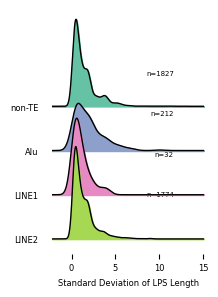

In [11]:
fig = plt.figure(figsize=(2.5, 3))
axes = joyplot(
    data=LPS_AATG[LPS_AATG.Stdev > 0],
    by="plot_label",
    column="Stdev",
    kind="kde",
    overlap=1,
    linewidth=1,
    color=colors_subset,
    ax=plt.gca(),
)
# set y-axis group label font size to 6
if isinstance(axes, tuple) and len(axes) > 1:
    axes_list = axes[1]
else:
    axes_list = axes if isinstance(axes, (list, tuple)) else [axes]
for a in axes_list:
    a.tick_params(axis='y', labelsize=6)
plt.xlabel("Standard Deviation of LPS Length", fontsize=6)
plt.gca().tick_params(axis='both', labelsize=6)

# add counts to the right of each density curve
group_counts = LPS_AATG.groupby("plot_label").size()
y_max = plt.gca().get_ylim()[1]
for i, group in enumerate(to_sort_by):
    count = group_counts.get(group, 0)
    plt.text(0.80, y_max * (0.75 - i * 0.165), f"n={count}", transform=plt.gca().transAxes, ha="right", va="top", fontsize=5)

# plt.tight_layout()
plt.savefig(f"{plot_dir}/figure3_AATG_stdev_lps.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3C

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)
/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,
/tmp/ipykernel_2338533/3417085382.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = LPS_AGAGGG.groupby("plot_label").size()


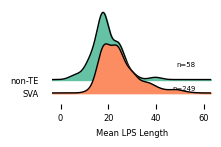

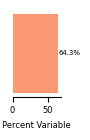

SVA 5'terminal mean: 25.69
non-TE non_mei mean: 19.27
SVA 5'terminal stdev: 3.15
non-TE non_mei stdev: 1.67


In [12]:
#plot a joyplot
# set the order of the plot_label to non-MEI, SVA, Alu, LINE1, LINE2
# get LPS_AGAGGG for 5' and non-MEI, don't include SVA since there are none
LPS_AGAGGG = LPS_variable[(LPS_variable.simple_motif == "AGAGGG")&(((LPS_variable.terminal_label == "5'terminal")&(LPS_variable.plot_label == "SVA"))|(LPS_variable.mei == False))].copy()
LPS_AGAGGG["plot_label"] = np.select(
    [
        LPS_AGAGGG["mei_family"].str.contains("Alu", na=False),
        LPS_AGAGGG["mei_family"].str.contains("SVA", na=False),
        LPS_AGAGGG["mei_family"].str.contains("L1", na=False),
        LPS_AGAGGG["mei_family"].str.contains("L2", na=False),
    ],
    ["Alu", "SVA", "LINE1", "LINE2"],
    default="non-TE",
)
to_sort_by = [x for x in ["non-TE", "SVA"] if x in LPS_AGAGGG["plot_label"].unique()]
LPS_AGAGGG["plot_label"] = pd.Categorical(LPS_AGAGGG["plot_label"], categories=to_sort_by, ordered=True)
fig = plt.figure(figsize=(2.5,1.5))
colors_subset = [colors_map[c] for c in to_sort_by]

axes = joyplot(
    data=LPS_AGAGGG[(LPS_AGAGGG.Mean < 60)&(LPS_AGAGGG.Stdev > 0)],
    by="plot_label",
    column="Mean",
    kind="kde",
    overlap=1,
    linewidth=1,
    color=colors_subset,  # use `color` not `colors`
    ax=plt.gca(),       # remove unsupported `order` argument
)
plt.xlabel('Mean LPS Length', fontsize=6)
# set the x ticks to fontsize 6
plt.gca().tick_params(axis='x', labelsize=6)
# set y-axis group label font size to 6
if isinstance(axes, tuple) and len(axes) > 1:
    axes_list = axes[1]
else:
    axes_list = axes if isinstance(axes, (list, tuple)) else [axes]
for a in axes_list:
    a.tick_params(axis='y', labelsize=6)
# plt.title("Mean LPS length for AGAGGG motif, 5' and non-MEI", fontsize=6)
# add the number of STRs in each group to the plot to the right of the density curves above the distribution for each
group_counts = LPS_AGAGGG.groupby("plot_label").size()
y_max = plt.gca().get_ylim()[1]
for i, group in enumerate(to_sort_by):
    count = group_counts.get(group, 0)
    plt.text(0.9, y_max * (0.45 - i * 0.25), f"n={count}", transform=plt.gca().transAxes, ha="right", va="top", fontsize=5)
# plt.tight_layout()
plt.savefig(f"{plot_dir}/figure3_AGAGGG_mean_lps.pdf", dpi=300, bbox_inches="tight")
plt.show()

# plot the percentage of variable STRs for the AGAGGG motif by plot_label and terminal_label as a vertical bar plot with color corresponding to the plot_label hue in the previous plots and plot it such that the y-axis heights correspond to the same heights as the density plot for the AGAGGG motif (so we can visually compare the percentage variable to the density distribution)
# add plot_label to LPS if it doesn't exist
if "plot_label" not in LPS.columns:
    LPS["plot_label"] = np.select(
        [
            LPS["mei_family"].str.contains("Alu", na=False),
            LPS["mei_family"].str.contains("SVA", na=False),
            LPS["mei_family"].str.contains("L1", na=False),
            LPS["mei_family"].str.contains("L2", na=False),
        ],
        ["Alu", "SVA", "LINE1", "LINE2"],
        default="non-TE",
    )
ACC_pct_df = LPS[LPS.simple_motif == "AGAGGG"].groupby(["plot_label", "terminal_label"], as_index=False).size().rename(columns={"size": "n_total"})
ACC_variable_df = LPS[(LPS.simple_motif == "AGAGGG")&(LPS.unique_lps > 1)].groupby(["plot_label", "terminal_label"], as_index=False).size().rename(columns={"size": "n_variable"})
ACC_pct_df = ACC_pct_df.merge(ACC_variable_df, on=["plot_label", "terminal_label"], how="left")
ACC_pct_df["n_variable"] = ACC_pct_df["n_variable"].fillna(0)
ACC_pct_df["pct_variable"] = 100 * ACC_pct_df["n_variable"] / ACC_pct_df["n_total"]

# Filter to only include the terminal_label categories that are in to_sort_by or non_mei for non-MEI
ACC_pct_df = ACC_pct_df[
    ((ACC_pct_df.plot_label == "SVA") & (ACC_pct_df.terminal_label.isin(["5'terminal"]))) |
    ((ACC_pct_df.plot_label == "non-TE") & (ACC_pct_df.terminal_label == "non_mei"))
]

# plot this as a horizontal bar plot with color corresponding to the plot_label hue in the previous plots
fig, ax = plt.subplots(figsize=(1, 1.5))
palette = sb.color_palette("Set2", n_colors=len(to_sort_by) + 1)
palette = [c for idx, c in enumerate(palette)][:len(to_sort_by)]  # skip 3rd color
colors = dict(zip(to_sort_by, palette))

y_pos = 0
y_labels = []
y_ticks = []

for i, group in enumerate(to_sort_by[::-1]):
    group_data = ACC_pct_df[ACC_pct_df.plot_label == group]
    if group == "non-TE":
        term_order = ["non_mei"]
    else:
        term_order = ["5'terminal"]
    
    for term in term_order:
        term_data = group_data[group_data.terminal_label == term]
        if not term_data.empty:
            pct = term_data.pct_variable.values[0]
            ax.barh(y_pos, pct, color=colors[group], alpha=0.9)
            y_labels.append(f"{group} - {term}")
            y_ticks.append(y_pos)
            y_pos += 1

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=6)
ax.set_xlabel("Percent Variable", fontsize=6)
# set the x ticks to fontsize 6
ax.tick_params(axis='x', labelsize=6)
# ax.set_title("Percent Variable STRs for ACC motif by MEI family and terminal label")
ax.grid(axis="x", alpha=0.2)

# add the percentage value to the right of each bar
for i, (y, label) in enumerate(zip(y_ticks, y_labels)):
    pct = ACC_pct_df[(ACC_pct_df.plot_label == label.split(" - ")[0]) & 
                      (ACC_pct_df.terminal_label == label.split(" - ")[1])].pct_variable.values[0]
    ax.text(pct + 1, y, f"{pct:.1f}%", va="center", fontsize=5)
# remove the y-axis label since it's redundant with the labels we added to the right of the bars
ax.set_yticks([])
# remove the box around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# remove the y axis line
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{plot_dir}/figure3_AGAGGG_pct_variable.pdf", dpi=300, bbox_inches="tight")
plt.show()

# print the mean of the Mean column for the AGAGGG motif for the SVA 5'terminal group and the non-MEI non_mei group
sva_5prime_mean = LPS_AGAGGG[(LPS_AGAGGG.plot_label == "SVA") & (LPS_AGAGGG.terminal_label == "5'terminal")]["Mean"].mean()
non_mei_mean = LPS_AGAGGG[(LPS_AGAGGG.plot_label == "non-TE") & (LPS_AGAGGG.terminal_label == "non_mei")]["Mean"].mean()
print(f"SVA 5'terminal mean: {sva_5prime_mean:.2f}")
print(f"non-TE non_mei mean: {non_mei_mean:.2f}")
# print the mean of the Stdev column for the AGAGGG motif for the SVA 5'terminal group and the non-MEI non_mei group
sva_5prime_stdev = LPS_AGAGGG[(LPS_AGAGGG.plot_label == "SVA") & (LPS_AGAGGG.terminal_label == "5'terminal")]["Stdev"].mean()
non_mei_stdev = LPS_AGAGGG[(LPS_AGAGGG.plot_label == "non-TE") & (LPS_AGAGGG.terminal_label == "non_mei")]["Stdev"].mean()
print(f"SVA 5'terminal stdev: {sva_5prime_stdev:.2f}")
print(f"non-TE non_mei stdev: {non_mei_stdev:.2f}")

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)
/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,
/tmp/ipykernel_2338533/3923632964.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = LPS_AGAGGG.groupby("plot_label").size()


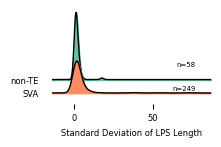

In [13]:
fig = plt.figure(figsize=(2.5,1.5))
axes = joyplot(
    data=LPS_AGAGGG[LPS_AGAGGG.Stdev > 0],
    by="plot_label",
    column="Stdev",
    kind="kde",
    overlap=1,
    linewidth=1,
    color=colors_subset,
    ax=plt.gca(),
)
plt.xlabel('Standard Deviation of LPS Length', fontsize=6)
plt.gca().tick_params(axis='x', labelsize=6)
if isinstance(axes, tuple) and len(axes) > 1:
    axes_list = axes[1]
else:
    axes_list = axes if isinstance(axes, (list, tuple)) else [axes]
for a in axes_list:
    a.tick_params(axis='y', labelsize=6)

group_counts = LPS_AGAGGG.groupby("plot_label").size()
y_max = plt.gca().get_ylim()[1]
for i, group in enumerate(to_sort_by):
    count = group_counts.get(group, 0)
    plt.text(0.9, y_max * (0.45 - i * 0.25), f"n={count}", transform=plt.gca().transAxes, ha="right", va="top", fontsize=5)

plt.savefig(f"{plot_dir}/figure3_AGAGGG_stdev_lps.pdf", dpi=300, bbox_inches="tight")
plt.show()


# Figure 3D

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)
/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,
/tmp/ipykernel_2338533/558695305.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = plot_data.groupby("plot_label").size().reindex(to_sort_by, fill_value=0)


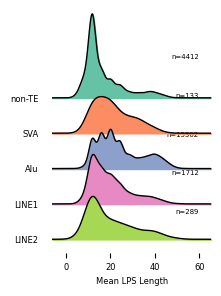

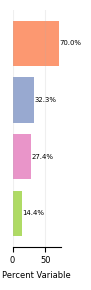

AAAT motif - Mean LPS Length:
plot_label  terminal_label
non-TE      3'terminal        22.583290
            non_mei           15.998246
SVA         3'terminal        20.952944
            non_mei                 NaN
Alu         3'terminal        23.977013
            non_mei                 NaN
LINE1       3'terminal        19.685246
            non_mei                 NaN
LINE2       3'terminal        19.750966
            non_mei                 NaN
Name: Mean, dtype: float64

AAAT motif - Stdev LPS Length:
plot_label  terminal_label
non-TE      3'terminal        2.366866
            non_mei           1.425824
SVA         3'terminal        2.130454
            non_mei                NaN
Alu         3'terminal        2.335990
            non_mei                NaN
LINE1       3'terminal        1.723526
            non_mei                NaN
LINE2       3'terminal        1.961033
            non_mei                NaN
Name: Stdev, dtype: float64


/tmp/ipykernel_2338533/558695305.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(aaat_joy.groupby(["plot_label", "terminal_label"])["Mean"].mean())
/tmp/ipykernel_2338533/558695305.py:165: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(aaat_joy.groupby(["plot_label", "terminal_label"])["Stdev"].mean())


,plot_label,terminal_label,n_total,n_variable,pct_variable
0,Alu,3'terminal,47390,15311,32.308504
1,LINE1,3'terminal,6251,1714,27.419613
2,LINE2,3'terminal,2012,289,14.363817
3,SVA,3'terminal,190,133,70.000000
4,non-MEI,3'terminal,1876,476,25.373134


In [14]:
# Percent variable for AAAT by plot_label + terminal_label (3'terminal / non_mei)
terminal_keep = ["3'terminal", "non_mei"]
aaat_joy = LPS_variable[
    (LPS_variable["simple_motif"] == "AAAT")
    & (LPS_variable["terminal_label"].isin(terminal_keep))
].copy()

# keep non_mei only for true non-MEI rows
aaat_joy = aaat_joy[
    (aaat_joy["terminal_label"] != "non_mei") | (aaat_joy["mei"] == False)
]

# build plot_label if missing and ensure ordering only for present labels
aaat_joy["plot_label"] = np.select(
    [
        aaat_joy["mei_family"].str.contains("Alu", na=False),
        aaat_joy["mei_family"].str.contains("SVA", na=False),
        aaat_joy["mei_family"].str.contains("L1", na=False),
        aaat_joy["mei_family"].str.contains("L2", na=False),
    ],
    ["Alu", "SVA", "LINE1", "LINE2"],
    default="non-TE",
)
to_sort_by = [x for x in ["non-TE", "SVA", "Alu", "LINE1", "LINE2"] if x in aaat_joy["plot_label"].unique()]
aaat_joy["plot_label"] = pd.Categorical(aaat_joy["plot_label"], categories=to_sort_by, ordered=True)

plot_data = aaat_joy[(aaat_joy["Stdev"] > 0) & (aaat_joy["Mean"] < 60)].copy()
colors_subset = [colors_map[c] for c in to_sort_by]

# Joyplot (match previous cell formatting)
fig = plt.figure(figsize=(2.5, 3))
axes = joyplot(
    data=plot_data,
    by="plot_label",
    column="Mean",
    kind="kde",
    overlap=1,
    linewidth=1,
    color=colors_subset,
    ax=plt.gca(),
)
plt.xlabel("Mean LPS Length", fontsize=6)
plt.gca().tick_params(axis="x", labelsize=6)

# ensure we set y-axis group label font size
if isinstance(axes, tuple) and len(axes) > 1:
    axes_list = axes[1]
else:
    axes_list = axes if isinstance(axes, (list, tuple)) else [axes]
for a in axes_list:
    a.tick_params(axis="y", labelsize=6)

# add group counts annotation (small font)
ax = plt.gca()
group_counts = plot_data.groupby("plot_label").size().reindex(to_sort_by, fill_value=0)
for i, group in enumerate(to_sort_by):
    count = int(group_counts.loc[group])
    ax.text(
        0.92,
        0.82 - i * 0.16,
        f"n={count}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=5,
    )
# plt.tight_layout()
plt.savefig(f"{plot_dir}/figure3_AAAT_mean_lps.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Percent-variable plot (AAAT) - match formatting from previous cell
# ----------------------------
if "plot_label" not in LPS.columns:
    LPS["plot_label"] = np.select(
        [
            LPS["mei_family"].str.contains("Alu", na=False),
            LPS["mei_family"].str.contains("SVA", na=False),
            LPS["mei_family"].str.contains("L1", na=False),
            LPS["mei_family"].str.contains("L2", na=False),
        ],
        ["Alu", "SVA", "LINE1", "LINE2"],
        default="non-TE",
    )

aaat_base = LPS[LPS["simple_motif"] == "AAAT"].copy()
aaat_base = aaat_base[
    ((aaat_base["plot_label"] != "non-TE") & (aaat_base["terminal_label"] == "3'terminal"))
    | (
        (aaat_base["plot_label"] == "non-TE")
        & (aaat_base["terminal_label"] == "non_mei")
        & (aaat_base["mei"] == False)
    )
].copy()

aaat_total = (
    aaat_base.groupby(["plot_label", "terminal_label"], as_index=False)
    .size()
    .rename(columns={"size": "n_total"})
)

aaat_variable = (
    aaat_base[aaat_base["unique_lps"] > 1]
    .groupby(["plot_label", "terminal_label"], as_index=False)
    .size()
    .rename(columns={"size": "n_variable"})
)

aaat_pct_df = aaat_total.merge(aaat_variable, on=["plot_label", "terminal_label"], how="left")
aaat_pct_df["n_variable"] = aaat_pct_df["n_variable"].fillna(0)
aaat_pct_df["pct_variable"] = 100 * aaat_pct_df["n_variable"] / aaat_pct_df["n_total"]

# Filter to only include relevant terminal_label categories (consistent with to_sort_by logic)
aaat_pct_df = aaat_pct_df[
    ((aaat_pct_df.plot_label == "non-TE") & (aaat_pct_df.terminal_label == "non_mei"))
    | ((aaat_pct_df.plot_label != "non-TE") & (aaat_pct_df.terminal_label == "3'terminal"))
]

fig, ax = plt.subplots(figsize=(1, 3))
palette = sb.color_palette("Set2", n_colors=len(to_sort_by) + 1)
palette = [c for idx, c in enumerate(palette)][:len(to_sort_by)]
colors = dict(zip(to_sort_by, palette))

y_pos = 0
y_labels, y_ticks = [], []

for group in to_sort_by[::-1]:
    group_data = aaat_pct_df[aaat_pct_df["plot_label"] == group]
    term_order = ["non_mei"] if group == "non-TE" else ["3'terminal"]
    for term in term_order:
        term_data = group_data[group_data["terminal_label"] == term]
        if not term_data.empty:
            pct = term_data["pct_variable"].iloc[0]
            ax.barh(y_pos, pct, color=colors[group], alpha=0.9)
            y_labels.append(f"{group} - {term}")
            y_ticks.append(y_pos)
            y_pos += 1

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=6)
ax.set_xlabel("Percent Variable", fontsize=6)
ax.tick_params(axis="x", labelsize=6)
ax.grid(axis="x", alpha=0.2)

for y, label in zip(y_ticks, y_labels):
    grp, term = label.split(" - ")
    pct = aaat_pct_df.loc[
        (aaat_pct_df["plot_label"] == grp) & (aaat_pct_df["terminal_label"] == term),
        "pct_variable",
    ].iloc[0]
    ax.text(pct + 0.8, y, f"{pct:.1f}%", va="center", fontsize=5)

ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{plot_dir}/figure3_AAAT_pct_variable.pdf", dpi=300, bbox_inches="tight")
plt.show()

# print mean/stdev summaries
print("AAAT motif - Mean LPS Length:")
print(aaat_joy.groupby(["plot_label", "terminal_label"])["Mean"].mean())
print("\nAAAT motif - Stdev LPS Length:")
print(aaat_joy.groupby(["plot_label", "terminal_label"])["Stdev"].mean())
aaat_pct_df

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)
/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,
/tmp/ipykernel_2338533/1837443331.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = plot_data.groupby("plot_label").size().reindex(to_sort_by, fill_value=0)


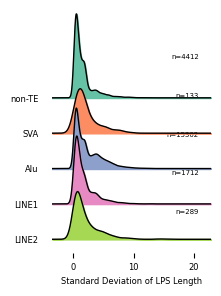

In [15]:
plot_data = aaat_joy[(aaat_joy["Stdev"] > 0) & (aaat_joy["Mean"] < 60)].copy()
colors_subset = [colors_map[c] for c in to_sort_by]

fig = plt.figure(figsize=(2.5, 3))
axes = joyplot(
    data=plot_data,
    by="plot_label",
    column="Stdev",
    kind="kde",
    overlap=1,
    linewidth=1,
    color=colors_subset,
    ax=plt.gca(),
)
plt.xlabel("Standard Deviation of LPS Length", fontsize=6)
plt.gca().tick_params(axis="x", labelsize=6)

if isinstance(axes, tuple) and len(axes) > 1:
    axes_list = axes[1]
else:
    axes_list = axes if isinstance(axes, (list, tuple)) else [axes]
for a in axes_list:
    a.tick_params(axis="y", labelsize=6)

ax = plt.gca()
group_counts = plot_data.groupby("plot_label").size().reindex(to_sort_by, fill_value=0)
for i, group in enumerate(to_sort_by):
    count = int(group_counts.loc[group])
    ax.text(
        0.92,
        0.82 - i * 0.16,
        f"n={count}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=5,
    )

plt.savefig(f"{plot_dir}/figure3_AAAT_stdev_lps.pdf", dpi=300, bbox_inches="tight")
plt.show()
